In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv("injury_data.csv")

print(df.head())

print("Shape of dataset:", df.shape)

               Name  Team Name     Position  Age   Season  FIFA rating  \
0  Jamaal Lascelles  Newcastle  Center Back   26  2019/20           77   
1      Fabian Schär  Newcastle  Center Back   28  2019/20           79   
2      Fabian Schär  Newcastle  Center Back   28  2019/20           79   
3      Fabian Schär  Newcastle  Center Back   28  2019/20           79   
4      Paul Dummett  Newcastle  Center Back   28  2019/20           75   

             Injury Date of Injury Date of return Match1_before_injury_Result  \
0       Knee injury    Nov 9, 2019   Jan 13, 2020                        draw   
1       Knee injury   Oct 20, 2019   Nov 24, 2019                        lose   
2  Hamstring strain    Jan 2, 2020   Jan 17, 2020                        lose   
3   Shoulder injury   Jul 16, 2020   Sep 28, 2020                        lose   
4      Groin injury   Dec 22, 2019   Jan 10, 2020                         win   

   ... Match1_after_injury_GD Match1_after_injury_Player_rating  \
0

In [4]:

print(df.info())


print(df.describe())

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Name                                656 non-null    object
 1   Team Name                           656 non-null    object
 2   Position                            656 non-null    object
 3   Age                                 656 non-null    int64 
 4   Season                              656 non-null    object
 5   FIFA rating                         656 non-null    int64 
 6   Injury                              656 non-null    object
 7   Date of Injury                      656 non-null    object
 8   Date of return                      656 non-null    object
 9   Match1_before_injury_Result         656 non-null    object
 10  Match1_before_injury_Opposition     656 non-null    object
 11  Match1_before_injury_GD             656 non-null    object

In [5]:
# Replace 'N.A.' values with actual NaN
df.replace("N.A.", np.nan, inplace=True)

# Check missing values
print(df.isnull().sum())

Name                                    0
Team Name                               0
Position                                0
Age                                     0
Season                                  0
FIFA rating                             0
Injury                                  0
Date of Injury                          0
Date of return                          0
Match1_before_injury_Result            65
Match1_before_injury_Opposition        65
Match1_before_injury_GD                65
Match1_before_injury_Player_rating     67
Match2_before_injury_Result           101
Match2_before_injury_Opposition       101
Match2_before_injury_GD               101
Match2_before_injury_Player_rating    102
Match3_before_injury_Result           157
Match3_before_injury_Opposition       157
Match3_before_injury_GD               157
Match3_before_injury_Player_rating    157
Match1_missed_match_Result              2
Match1_missed_match_Opposition          2
Match1_missed_match_GD            

In [6]:
# Convert injury dates to datetime format
df['Date of Injury'] = pd.to_datetime(df['Date of Injury'], errors='coerce')
df['Date of return'] = pd.to_datetime(df['Date of return'], errors='coerce')

In [7]:
# Convert rating columns to numeric
rating_cols = [col for col in df.columns if "rating" in col.lower()]

for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [9]:
# Calculate injury duration in days
df['Injury_duration_days'] = (df['Date of return'] - df['Date of Injury']).dt.days

print(df['Injury_duration_days'].head())

0    65.0
1    35.0
2    15.0
3    74.0
4    19.0
Name: Injury_duration_days, dtype: float64


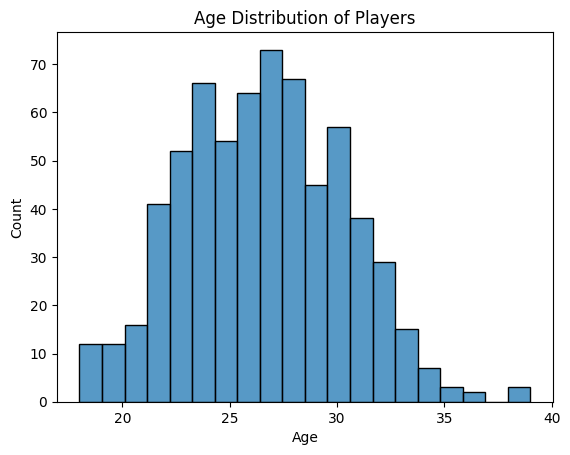

In [10]:
plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

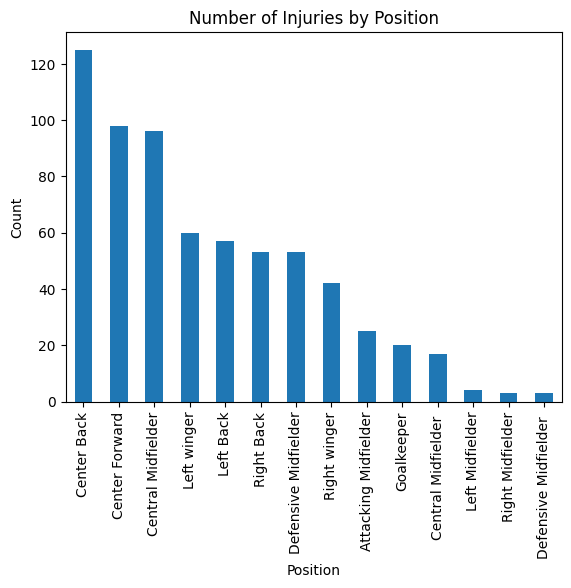

In [11]:
plt.figure()
df['Position'].value_counts().plot(kind='bar')
plt.title("Number of Injuries by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

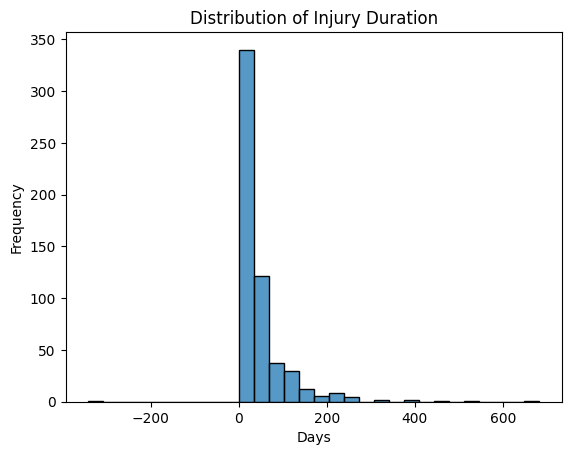

In [12]:
plt.figure()
sns.histplot(df['Injury_duration_days'], bins=30)
plt.title("Distribution of Injury Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

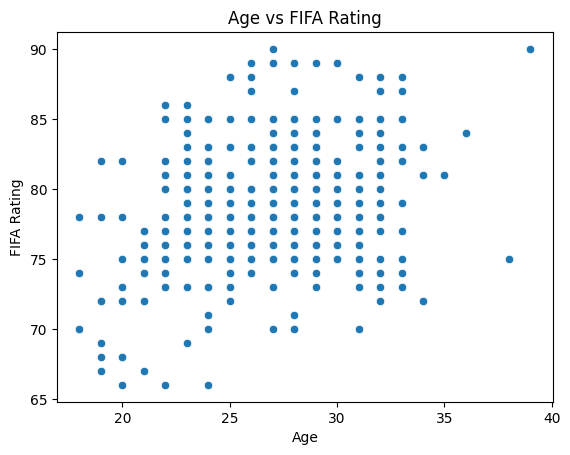

In [13]:
plt.figure()
sns.scatterplot(x=df['Age'], y=df['FIFA rating'])
plt.title("Age vs FIFA Rating")
plt.xlabel("Age")
plt.ylabel("FIFA Rating")
plt.show()

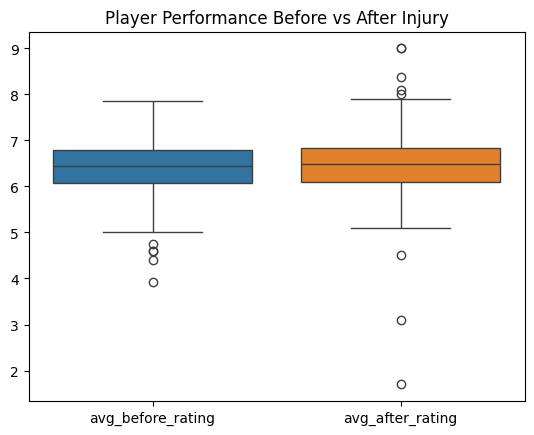

In [14]:
# Calculate average ratings
before_cols = [col for col in df.columns if "before_injury_Player_rating" in col]
after_cols = [col for col in df.columns if "after_injury_Player_rating" in col]

df['avg_before_rating'] = df[before_cols].mean(axis=1)
df['avg_after_rating'] = df[after_cols].mean(axis=1)

# Plot comparison
plt.figure()
sns.boxplot(data=df[['avg_before_rating','avg_after_rating']])
plt.title("Player Performance Before vs After Injury")
plt.show()

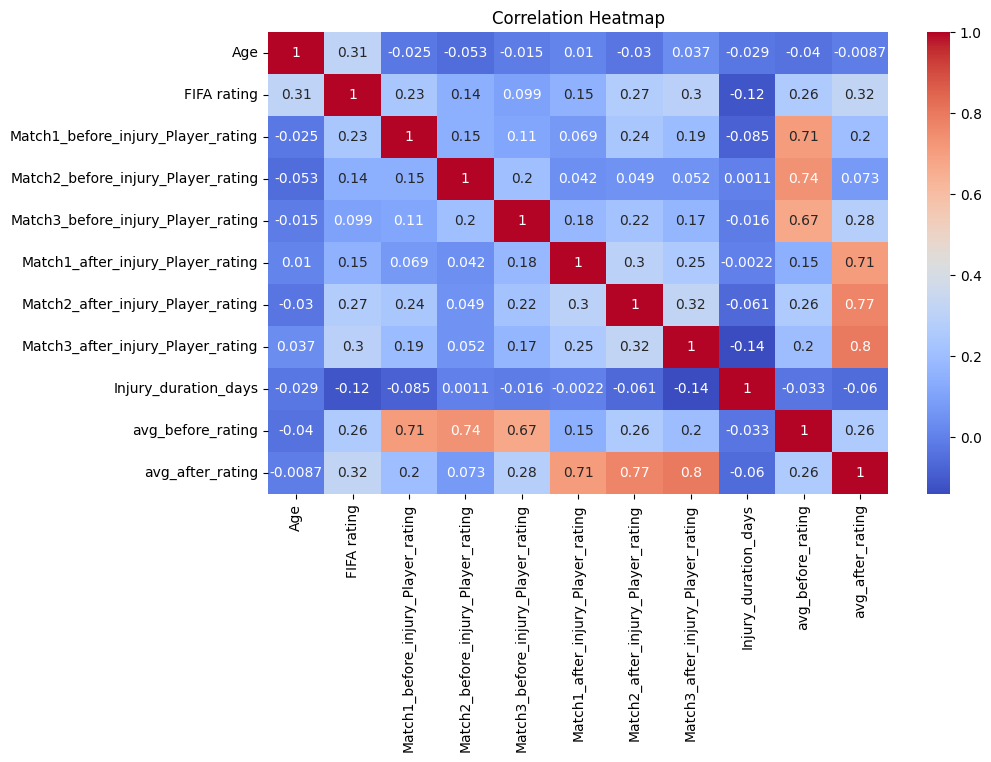

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Save cleaned dataset
df.to_csv("cleaned_injury_dataset.csv", index=False)